In [1]:
# Mount Google Drive (for Google Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✅ Google Drive mounted successfully!")
except ImportError:
    IN_COLAB = False
    print("ℹ️  Not running in Google Colab - skipping drive mount")

# Set project root path
if IN_COLAB:
    PROJECT_ROOT = "/content/drive/MyDrive/face_based_attendance_system"
else:
    from pathlib import Path
    PROJECT_ROOT = str(Path("..").resolve())

print(f"📂 Project root: {PROJECT_ROOT}")

ℹ️  Not running in Google Colab - skipping drive mount
📂 Project root: C:\Users\User\Desktop\AI_ML\face-based_attendance_system


# 03 - Model Architecture Deep Dive

This notebook provides a detailed exploration of the MobileFaceNet + ArcFace architecture.

## Topics Covered:
1. MobileFaceNet Architecture Analysis
2. Depthwise Separable Convolutions
3. ECA (Efficient Channel Attention)
4. ArcFace Loss Mathematics
5. Model Visualization and Statistics

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchinfo import summary
import math

print(f"PyTorch: {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

PyTorch: 2.2.2+cpu
Device: cpu


## 1. Understanding Depthwise Separable Convolutions

Depthwise separable convolutions are key to MobileFaceNet's efficiency.

In [4]:
class StandardConv(nn.Module):
    """Standard convolution for comparison."""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size,
            stride=stride, padding=kernel_size//2, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.PReLU(out_channels)
    
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class DepthwiseSeparableConv(nn.Module):
    """
    Depthwise Separable Convolution.
    
    Standard conv: (C_in × C_out × K × K) parameters
    Depthwise separable: (C_in × K × K) + (C_in × C_out) parameters
    
    Reduction factor: K² × C_out / (K² + C_out)
    For K=3, C_out=64: ~8x reduction
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super().__init__()
        # Depthwise: each channel convolved separately
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size,
            stride=stride, padding=kernel_size//2,
            groups=in_channels,  # Key: groups = in_channels
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(in_channels)
        
        # Pointwise: 1x1 conv to combine channels
        self.pointwise = nn.Conv2d(
            in_channels, out_channels, 1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.PReLU(out_channels)
    
    def forward(self, x):
        x = self.bn1(self.depthwise(x))
        x = self.act(self.bn2(self.pointwise(x)))
        return x


# Compare parameter counts
in_ch, out_ch = 64, 128
standard = StandardConv(in_ch, out_ch, kernel_size=3)
separable = DepthwiseSeparableConv(in_ch, out_ch, kernel_size=3)

standard_params = sum(p.numel() for p in standard.parameters())
separable_params = sum(p.numel() for p in separable.parameters())

print(f"Standard Conv params: {standard_params:,}")
print(f"Depthwise Separable params: {separable_params:,}")
print(f"Reduction: {standard_params/separable_params:.2f}x")

Standard Conv params: 74,112
Depthwise Separable params: 9,280
Reduction: 7.99x


## 2. Efficient Channel Attention (ECA)

ECA provides channel attention with minimal overhead.

In [7]:
class ECABlock(nn.Module):
    """
    Efficient Channel Attention (ECA).
    
    Unlike SE (Squeeze-and-Excitation) which uses FC layers,
    ECA uses adaptive 1D convolution for cross-channel interaction.
    
    Advantages:
    - No dimensionality reduction (no information loss)
    - Adaptive kernel size based on channel count
    - Fewer parameters than SE
    """
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        # Adaptive kernel size based on channels
        kernel_size = int(abs((math.log2(channels) + b) / gamma))
        kernel_size = kernel_size if kernel_size % 2 else kernel_size + 1
        kernel_size = max(3, kernel_size)
        
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            1, 1, kernel_size=kernel_size,
            padding=kernel_size // 2, bias=False
        )
        self.sigmoid = nn.Sigmoid()
        
        self.kernel_size = kernel_size
    
    def forward(self, x):
        # Global average pooling: (B, C, H, W) -> (B, C, 1, 1)
        y = self.avg_pool(x)
        
        # Reshape for 1D conv: (B, C, 1, 1) -> (B, 1, C)
        y = y.squeeze(-1).transpose(-1, -2)
        
        # 1D conv across channels
        y = self.conv(y)
        
        # Reshape back: (B, 1, C) -> (B, C, 1, 1)
        y = y.transpose(-1, -2).unsqueeze(-1)
        
        # Apply attention
        return x * self.sigmoid(y)


# Test ECA block
def test_eca(channels=64):
    eca = ECABlock(channels)
    print(f"✓ ECA Block created for {channels} channels")
    print(f"  Adaptive kernel size: {eca.kernel_size}")
    
    # Test forward pass
    x = torch.randn(2, channels, 14, 14)
    output = eca(x)
    
    print(f"✓ Forward pass successful")
    print(f"  Input shape:  {x.shape}")
    print(f"  Output shape: {output.shape}")
    
    # Get attention weights
    with torch.no_grad():
        y = eca.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = eca.conv(y)
        weights = eca.sigmoid(y).squeeze()
        
        print(f"✓ Attention weights computed")
        print(f"  Weights shape: {weights.shape}")
        print(f"  Weight range: [{weights.min():.4f}, {weights.max():.4f}]")
        print(f"  Mean weight: {weights.mean():.4f}")

test_eca(64)

✓ ECA Block created for 64 channels
  Adaptive kernel size: 3
✓ Forward pass successful
  Input shape:  torch.Size([2, 64, 14, 14])
  Output shape: torch.Size([2, 64, 14, 14])
✓ Attention weights computed
  Weights shape: torch.Size([2, 64])
  Weight range: [0.4802, 0.5218]
  Mean weight: 0.4999


## 3. Complete MobileFaceNet Architecture

In [8]:
class InvertedResidual(nn.Module):
    """
    Inverted Residual Block (MobileNetV2-style).
    
    1. Expansion (1x1 conv): C -> C*expand_ratio
    2. Depthwise (3x3 conv): spatial filtering
    3. Projection (1x1 conv): C*expand_ratio -> out_channels
    """
    def __init__(self, in_channels, out_channels, stride, expand_ratio, use_eca=True):
        super().__init__()
        hidden_dim = in_channels * expand_ratio
        self.use_residual = stride == 1 and in_channels == out_channels
        
        layers = []
        
        # Expansion
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.PReLU(hidden_dim)
            ])
        
        # Depthwise
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.PReLU(hidden_dim)
        ])
        
        # ECA attention
        if use_eca:
            layers.append(ECABlock(hidden_dim))
        
        # Projection
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])
        
        self.conv = nn.Sequential(*layers)
    
    def forward(self, x):
        if self.use_residual:
            return x + self.conv(x)
        return self.conv(x)


class MobileFaceNet(nn.Module):
    """
    MobileFaceNet for face recognition.
    
    Architecture optimized for:
    - 112x112 input size
    - 512-dimensional embeddings
    - < 1M parameters
    - < 5ms inference on mobile
    """
    def __init__(self, embedding_dim=512, use_eca=True):
        super().__init__()
        
        # Initial stem
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU(64)
        )
        
        # Depthwise for first layer
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1, groups=64, bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU(64)
        )
        
        # Bottleneck stages: (expand_ratio, out_channels, num_blocks, stride)
        bottleneck_settings = [
            (2, 64, 5, 2),    # Stage 1: 56x56 -> 28x28
            (4, 128, 1, 2),   # Stage 2: 28x28 -> 14x14
            (2, 128, 6, 1),   # Stage 3: 14x14
            (4, 128, 1, 2),   # Stage 4: 14x14 -> 7x7
            (2, 128, 2, 1),   # Stage 5: 7x7
        ]
        
        self.bottlenecks = self._make_bottlenecks(bottleneck_settings, 64, use_eca)
        
        # Final layers
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.PReLU(512)
        )
        
        # Global Depthwise Conv (replaces global avg pool)
        self.conv4 = nn.Sequential(
            nn.Conv2d(512, 512, 7, 1, 0, groups=512, bias=False),
            nn.BatchNorm2d(512)
        )
        
        # Final embedding
        self.fc = nn.Linear(512, embedding_dim, bias=False)
        self.bn = nn.BatchNorm1d(embedding_dim)
        
        self._initialize_weights()
    
    def _make_bottlenecks(self, settings, in_channels, use_eca):
        layers = []
        for expand_ratio, out_channels, num_blocks, stride in settings:
            for i in range(num_blocks):
                s = stride if i == 0 else 1
                layers.append(InvertedResidual(in_channels, out_channels, s, expand_ratio, use_eca))
                in_channels = out_channels
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
    
    def forward(self, x):
        x = self.conv1(x)      # 112x112 -> 56x56
        x = self.conv2(x)      # 56x56
        x = self.bottlenecks(x)  # -> 7x7
        x = self.conv3(x)      # 7x7, 512 channels
        x = self.conv4(x)      # 1x1
        x = x.flatten(1)
        x = self.fc(x)
        x = self.bn(x)
        # L2 normalize for cosine similarity
        x = F.normalize(x, p=2, dim=1)
        return x


# Create and analyze model
model = MobileFaceNet(embedding_dim=512)
print(f"\nModel Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model Size: {sum(p.numel() for p in model.parameters()) * 4 / 1024 / 1024:.2f} MB (FP32)")


Model Parameters: 1,200,587
Model Size: 4.58 MB (FP32)


In [9]:
# Detailed model summary
try:
    summary(model, input_size=(1, 3, 112, 112), col_names=['input_size', 'output_size', 'num_params', 'kernel_size'])
except:
    # Fallback if torchinfo not available
    print("\nModel structure:")
    print(model)

## 4. ArcFace Loss: The Mathematics

ArcFace adds an angular margin to the target logit:

$L = -\log \frac{e^{s \cdot \cos(\theta_{y_i} + m)}}{e^{s \cdot \cos(\theta_{y_i} + m)} + \sum_{j \neq y_i} e^{s \cdot \cos \theta_j}}$

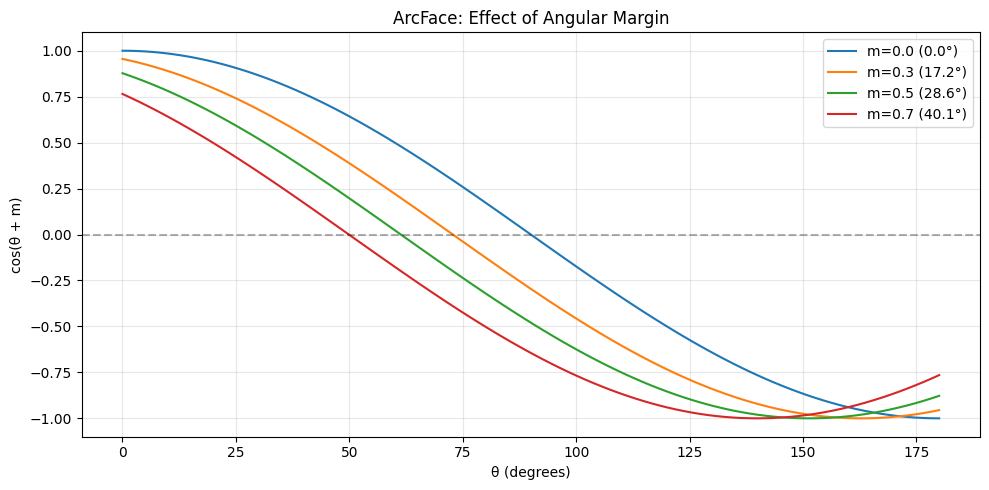

In [10]:
class ArcFaceLoss(nn.Module):
    """
    ArcFace: Additive Angular Margin Loss.
    
    The angular margin m (in radians) creates larger inter-class
    separation in the angular space.
    
    Args:
        embedding_dim: Dimension of face embeddings
        num_classes: Number of identities
        scale: Feature scale (s)
        margin: Angular margin in radians (m)
    """
    def __init__(self, embedding_dim, num_classes, scale=64.0, margin=0.5):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.scale = scale
        self.margin = margin
        
        # Class weight matrix (learned prototypes)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Precompute margin values
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold
        self.mm = math.sin(math.pi - margin) * margin
        
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (B, embedding_dim) L2-normalized embeddings
            labels: (B,) class labels
        """
        # Normalize weights
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        
        # sin(theta) from cos(theta)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2).clamp(0, 1))
        
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        
        # Handle edge case when theta + m > pi
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot encoding
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        
        # Apply margin only to target class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output = output * self.scale
        
        loss = self.criterion(output, labels)
        return loss, output


# Visualize angular margin effect
def visualize_arcface_margin():
    """Visualize how ArcFace margin affects decision boundary."""
    theta = np.linspace(0, np.pi, 100)
    margins = [0.0, 0.3, 0.5, 0.7]
    
    plt.figure(figsize=(10, 5))
    
    for m in margins:
        cos_m = np.cos(m)
        sin_m = np.sin(m)
        cosine = np.cos(theta)
        sine = np.sin(theta)
        phi = cosine * cos_m - sine * sin_m
        plt.plot(np.degrees(theta), phi, label=f'm={m} ({np.degrees(m):.1f}°)')
    
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.xlabel('θ (degrees)')
    plt.ylabel('cos(θ + m)')
    plt.title('ArcFace: Effect of Angular Margin')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_arcface_margin()

## 5. Inference Speed Benchmarking

In [11]:
import time

def benchmark_inference(model, input_size=(1, 3, 112, 112), num_runs=100, warmup=10):
    """Benchmark model inference speed."""
    model.eval()
    device = next(model.parameters()).device
    
    # Create dummy input
    x = torch.randn(input_size).to(device)
    
    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Benchmark
    times = []
    with torch.no_grad():
        for _ in range(num_runs):
            start = time.perf_counter()
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000)  # ms
    
    times = np.array(times)
    print(f"\nInference Benchmark ({device}):")
    print(f"  Mean: {times.mean():.2f} ms")
    print(f"  Std:  {times.std():.2f} ms")
    print(f"  Min:  {times.min():.2f} ms")
    print(f"  Max:  {times.max():.2f} ms")
    print(f"  FPS:  {1000/times.mean():.1f}")
    
    return times

# Benchmark on available device
model = model.to(DEVICE)
times = benchmark_inference(model, num_runs=100)


Inference Benchmark (cpu):
  Mean: 26.40 ms
  Std:  2.34 ms
  Min:  20.49 ms
  Max:  33.24 ms
  FPS:  37.9


## 6. Summary

### Key Takeaways:

1. **Depthwise Separable Convolutions**: ~8x parameter reduction vs standard conv
2. **ECA Attention**: Efficient channel attention with adaptive kernel size
3. **MobileFaceNet**: ~1M params, 512-dim embeddings, optimized for 112x112 input
4. **ArcFace Loss**: Angular margin creates better inter-class separation

### Next Steps:
- Proceed to training optimization notebook
- Configure AMP and Partial FC for efficient training